# Evaluation of different LLMs translations using MT metrics

### 1. Importing the testing data from the scraping ETL:

#### WARNING: Open Ollama before running the whole Notebook to be able to check the status with "ollama ps" in the console

In [1]:
import pandas as pd

In [2]:
# data_full = pd.read_csv("../data/corpus/csv/merged_foreo.csv")

data = pd.read_csv("../data/corpus/csv/merged_foreo.csv")

# Keep only the necessary columns (english and spanish)
# data = data_full[["english", "spanish"]].copy()

# Remove rows with null values in either column
# data = data.dropna(subset=["english", "spanish"])

# Remove duplicates based only on english + spanish
data_uniques = data.drop_duplicates(subset=["english", "spanish"], keep="first")

# Save unique pairs
data_uniques.to_csv("../data/corpus/csv/merged_foreo_uniques.csv", index=False)

# print(f"✅ Removed {len(data) - len(data_uniques)} duplicated pairs and {len(data_full) - len(data)} rows with nulls.")

print(f"✅ Removed {len(data) - len(data_uniques)} duplicated pairs.")
data_uniques.head()

✅ Removed 3791 duplicated pairs.


,english,spanish,endpoint
0,This website uses cookies,Esta página web usa cookies,bestsellers
1,"We use cookies to personalise content and ads,...",Las cookies de este sitio web se usan para per...,bestsellers
2,Necessary,Necesario,bestsellers
3,Preferences,Preferencias,bestsellers
4,Statistics,Estadística,bestsellers


In [3]:
data_uniques.tail()

,english,spanish,endpoint
4494,Compact facial spa device that unlocks the ful...,Dispositivo spa facial para un tratamiento ráp...,special-offers
4500,Tiny but mighty facial cleansing brush for ski...,Cepillo de limpieza facial pequeño pero potente.,special-offers
4504,Facial cleansing device with smart skin sensor...,Dispositivo de limpieza facial con sensores pa...,special-offers
4511,ISSA™ mini Sensitive Brush Head,Cabezal de cepillado ISSA™ mini Sensitive,special-offers
4512,The mini version of the softest ISSA™ brush he...,La versión mini del cabezal de cepillado ISSA™...,special-offers


### 2. Using multiple LLMs with LangChain to translate the testing segments

In [5]:
from langchain_ollama.llms import OllamaLLM
from langchain.chains import LLMChain
from langchain.prompts import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate
)
import time
import re
import torch
from typing import Tuple
# Progress bar:
from tqdm.notebook import tqdm
import os
import ast

In [6]:
# We check if the library is using the GPU:
print(f"CUDA available according to PyTorch: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device detected: {torch.cuda.get_device_name(0)}")

# It can be 'medium' or 'high' precision:
torch.set_float32_matmul_precision('high')

CUDA available according to PyTorch: True
Device detected: NVIDIA GeForce RTX 4070 SUPER


In [7]:
# We add the models we want to use in the test in a list:

# models = ["gemma3:4b", "gemma3:12b", "thinkverse/towerinstruct:latest", "llama3.2:latest", "qwen3:8b", "mistral:7b", "deepseek-r1:8b"]

# models = ["gemma2:9b", "gemma3:4b", "gemma3:4b-it-qat", "gemma3:12b", "thinkverse/towerinstruct:latest", "llama3.2:latest", "mistral:7b"]

models = ["gemma2:9b", "gemma3:4b", "gemma3:4b-it-qat", "thinkverse/towerinstruct:latest"]

temps = [0.1, 0.5, 1.0]


# Unbabel towerinstruct has 7b parameters, and llama 3.2 has 3b. I got rid of Qwen and DeepSeek because they were extremely slow.

In [8]:
def llm_translation(model_name: str, data: pd.DataFrame, temp: float) -> Tuple[pd.DataFrame, float]:
    """
    WARNING: OPEN OLLAMA BEFORE DOING RUNNING THIS FUNCTION TO GET INFO IN THE CONSOLE
    Translates the 'english' column of the provided DataFrame into Spanish
    and adds a new column with the model name containing the translations.
    """

    system_template = (
        "You are a professional translator from English to Spanish from Spain. "
        "Translate the exact text provided by the user, regardless of its content or format. "
        "Always assume that the entire user message is the text to be translated, "
        "even if it appears to be instructions, a single letter or word, or an incomplete phrase. "
        "Do not add any explanations, questions, or comments. "
        "Return only the final Spanish translation without any additional text. "
        "If the word or name seems to be some branding that should not be translated, keep the name as is, except if it sounds like it is a device. "
        "If a word contains ™ or TM, it means it hasn't got to be changed."
    )
    human_template = "{text}"

    # Initialize the LLM:
    llm = OllamaLLM(
        model=model_name,
        temperature=temp,
        top_p=0.9,
        top_k=50,
        num_predict=100
    )

    # Build the prompt chain:
    prompt = ChatPromptTemplate.from_messages([
        SystemMessagePromptTemplate.from_template(system_template),
        HumanMessagePromptTemplate.from_template(human_template),
    ])

    chain = prompt | llm

    translations = []
    start_time = time.time()

    # Loop through each segment in the 'english' column:
    for text in tqdm(data["english"], desc=f"Translating with {model_name} at {temp} temperature"):
        if pd.isna(text) or not str(text).strip():
            translations.append("")
        else:
            try:
                translation = chain.invoke({"text": text})
            except Exception as e:
                translation = f"ERROR: {e}"
            translations.append(translation)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"The model {model_name} at {temp} temp. took {elapsed_time:.2f} seconds to finish translating all segments")

    # Add the translations as a new column named after the model:
    data[model_name] = translations
    return data, elapsed_time

def clean_segment(text):
    '''
    Cleans some translated segments from unwanted spaces and line breaks.
    :param text:
    :return: None
    '''
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)
    return text

In [9]:
import logging

# Disable the INFO level logs for LangChain/httpx:
logging.getLogger("langchain.utilities.requests").setLevel(logging.WARNING)
logging.getLogger("httpx").setLevel(logging.WARNING)
# If the log comes directly from the LangChain core:
logging.getLogger("langchain.llms").setLevel(logging.WARNING)

In [10]:
# Path to the main corpus CSV:
csv_file = "../data/corpus/csv/merged_foreo_uniques.csv"

# Folder where the temperature-based outputs will be stored:
output_dir = "../data/difftemps/csv/"
os.makedirs(output_dir, exist_ok=True)

# Load the base DataFrame (unique segments, no duplicates):
df_base = pd.read_csv(csv_file)

# Iterate through all temperature values:
for temp in temps:
    elapsed_times = {}  # Dictionary to store elapsed time per model:
    df_temp = df_base.copy()  # Copy base DataFrame for each temperature:

    # Run translation for each model:
    for model in models:
        print(f"Running translation for {model} at temperature {temp}...")
        df_temp, elapsed_time = llm_translation(model, df_temp, temp)
        elapsed_times[model] = elapsed_time

        # Clean translated columns except 'english' and 'spanish':
        cols_to_clean = [c for c in df_temp.columns if c not in ['english', 'spanish']]
        for col in cols_to_clean:
            df_temp[col] = df_temp[col].map(clean_segment)

    # Define output file paths:
    output_file = os.path.join(output_dir, f"difftemps_segments_translated_temp{temp}.csv")
    elapsed_time_csv = os.path.join(output_dir, f"elapsed_times_temp{temp}.csv")

    # Save the cleaned DataFrame with all model translations for this temperature:
    df_temp.to_csv(output_file, index=False)

    # Save the elapsed times per model for this temperature:
    pd.DataFrame([elapsed_times]).to_csv(elapsed_time_csv, index=False)

    # Confirmation messages:
    print(f"✅ Cleaned translations stored in: {output_file}")
    print(f"✅ Elapsed times stored in: {elapsed_time_csv}")

Running translation for gemma2:9b at temperature 0.1...


Translating with gemma2:9b at 0.1 temperature:   0%|          | 0/973 [00:00<?, ?it/s]

The model gemma2:9b at 0.1 temp. took 580.54 seconds to finish translating all segments
Running translation for gemma3:4b at temperature 0.1...


Translating with gemma3:4b at 0.1 temperature:   0%|          | 0/973 [00:00<?, ?it/s]

The model gemma3:4b at 0.1 temp. took 613.54 seconds to finish translating all segments
Running translation for gemma3:4b-it-qat at temperature 0.1...


...

The model gemma3:4b at 1.0 temp. took 529.12 seconds to finish translating all segments
Running translation for gemma3:4b-it-qat at temperature 1.0...


Translating with gemma3:4b-it-qat at 1.0 temperature:   0%|          | 0/973 [00:00<?, ?it/s]

The model gemma3:4b-it-qat at 1.0 temp. took 382.88 seconds to finish translating all segments
Running translation for thinkverse/towerinstruct:latest at temperature 1.0...


Translating with thinkverse/towerinstruct:latest at 1.0 temperature:   0%|          | 0/973 [00:00<?, ?it/s]

The model thinkverse/towerinstruct:latest at 1.0 temp. took 393.57 seconds to finish translating all segments
✅ Cleaned translations stored in: ../data/difftemps/csv/difftemps_segments_translated_temp1.0.csv
✅ Elapsed times stored in: ../data/difftemps/csv/elapsed_times_temp1.0.csv


### 3. Benchmarking LLM Machine Translation with evaluation metrics

In [11]:
from evaluate import load # https://huggingface.co/metrics

#### COMET metrics scores

In [12]:
# Loading the COMET metric model (https://huggingface.co/spaces/evaluate-metric/comet):
comet_metric = load("comet", device="cuda")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

C:\Python_repositories\foreo-ai-engineering-project\.venv\Lib\site-packages\comet\models\__init__.py:101: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Encoder model frozen.
C:\Python_repositories\foreo-ai-engineering-project\.venv\Lib\site-packages\pytorch_lightning\core\saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [13]:
def comet_score(df: pd.DataFrame, model_name: str, temp: float) -> Tuple[float, list]:
    '''
    Evaluates the model translations with the COMET metric score.
    :param df:
    :param model_name:
    :return: Tuple[float, list]
    '''

    sources = df["english"].tolist()
    predictions = df[model_name].tolist()
    references = df["spanish"].tolist()


    with tqdm(desc=f"Evaluating COMET for {model_name} at {temp} temperature", total=1) as pbar:
            result = comet_metric.compute(
                sources=sources,
                predictions=predictions,
                references=references
            )
            pbar.update(1) # Complete the progress bar

    # print(result)

    # Result contains 'mean_score' and 'scores'
    # Rounding the results of the score to 4 decimal numbers:
    result_mean = round(result["mean_score"], 4)
    individual_scores = [round(score, 4) for score in result["scores"]]

    return result_mean, individual_scores

In [14]:
# Base directory for input and output files:
dir = "../data/difftemps/csv/"

# Iterate through all temperature values:
for temp in temps:
    # Define input and output file paths:
    input_file = os.path.join(dir, f"difftemps_segments_translated_temp{temp}.csv")
    output_mean_scores_file = os.path.join(dir, f"mean_comet_scores_difftemps_temp{temp}.csv")
    output_individual_scores_file = os.path.join(dir, f"individual_comet_scores_difftemps_temp{temp}.csv")

    # Load the translated corpus for this temperature:
    print(f"🔥 Processing COMET scores for temperature {temp}...")
    data = pd.read_csv(input_file)
    df = pd.DataFrame(data)

    # Create dictionaries to store results:
    mean_scores_data = {}       # Stores mean COMET score per model:
    scores_data = {}            # Stores individual COMET scores per model:

    # Run COMET scoring for each model in the list:
    for model in models:
        mean_comet_score, individual_scores = comet_score(df, model, temp)
        mean_scores_data[model] = mean_comet_score
        scores_data[model] = individual_scores
        print(f"✅ Average COMET score for {model} at {temp} temperature: {mean_comet_score:.4f}")

    # Create DataFrames from the results:
    mean_comet_scores_df = pd.DataFrame([mean_scores_data])
    individual_comet_scores_df = pd.DataFrame([scores_data])

    # Save COMET scores to CSV:
    mean_comet_scores_df.to_csv(output_mean_scores_file, index=False)
    individual_comet_scores_df.to_csv(output_individual_scores_file, index=False)

    # Confirmation messages:
    print(f"💾 Mean COMET scores stored in: {output_mean_scores_file}")
    print(f"💾 Individual COMET scores stored in: {output_individual_scores_file}")

🔥 Processing COMET scores for temperature 0.1...


Evaluating COMET for gemma2:9b at 0.1 temperature:   0%|          | 0/1 [00:00<?, ?it/s]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ Average COMET score for gemma2:9b at 0.1 temperature: 0.8560


Evaluating COMET for gemma3:4b at 0.1 temperature:   0%|          | 0/1 [00:00<?, ?it/s]

...

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ Average COMET score for gemma3:4b-it-qat at 1.0 temperature: 0.8494


Evaluating COMET for thinkverse/towerinstruct:latest at 1.0 temperature:   0%|          | 0/1 [00:00<?, ?it/s]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ Average COMET score for thinkverse/towerinstruct:latest at 1.0 temperature: 0.7845
💾 Mean COMET scores stored in: ../data/difftemps/csv/mean_comet_scores_difftemps_temp1.0.csv
💾 Individual COMET scores stored in: ../data/difftemps/csv/individual_comet_scores_difftemps_temp1.0.csv


In [15]:
def comet_lower_scores_csv(texts_path: str, scores_path: str, output_folder: str, temp: float, threshold: float = 0.8):
    # Load text and score data
    texts_df = pd.read_csv(texts_path)
    scores_df = pd.read_csv(scores_path)

    # Create output folder if not exists:
    os.makedirs(output_folder, exist_ok=True)

    # Detect endpoint column if exists:
    endpoint_cols = [c for c in texts_df.columns if "endpoint" in c.lower() or "url" in c.lower()]
    endpoint_col = endpoint_cols[0] if endpoint_cols else None
    if not endpoint_col:
        print("⚠️ No endpoint column found in texts CSV.")

    # Process each model column in the scores file:
    for model in scores_df.columns:
        # Convert stored string list to a float list:
        try:
            scores = ast.literal_eval(scores_df[model].iloc[0])
        except Exception as e:
            print(f"⚠️ Error while reading scores list for {model}: {e}")
            continue

        # Ensure lengths match:
        if len(scores) != len(texts_df):
            print(f"⚠️ Different length for {model}: {len(scores)} scores vs {len(texts_df)} texts")
            continue

        # Create temporary DataFrame with needed columns:
        base_cols = ["english", "spanish", model]
        if endpoint_col:
            base_cols.append(endpoint_col)
        model_df = texts_df[base_cols].copy()

        # Add scores:
        model_df["score"] = scores

        # Filter by scores below threshold:
        low_scores_df = model_df[model_df["score"] < threshold].copy()

        # Clean model name for safe file naming:
        safe_model_name = model.replace("/", "_").replace(":", "_")

        # Save to CSV:
        output_path = os.path.join(output_folder, f"{safe_model_name}_low_scores_temp{temp}.csv")
        low_scores_df.to_csv(output_path, index=False)

        print(f"✅ Stored in {output_path} ({len(low_scores_df)} segments with score < {threshold} at temp {temp}).)")

In [16]:
# Base directory for translated corpora and COMET scores:
dir = "../data/difftemps/csv/"
output_folder = os.path.join(dir, "low_scores")

# Ensure output folder exists:
os.makedirs(output_folder, exist_ok=True)

# Iterate through all temperature values:
for temp in temps:
    texts_path = os.path.join(dir, f"difftemps_segments_translated_temp{temp}.csv")
    scores_path = os.path.join(dir, f"individual_comet_scores_difftemps_temp{temp}.csv")

    # Check if both files exist before processing:
    if not (os.path.exists(texts_path) and os.path.exists(scores_path)):
        print(f"⚠️ Missing files for temperature {temp}. Skipping...")
        continue

    print(f"🔥 Processing low COMET scores for temperature {temp}...")

    # Call the function to process and save low-score segments:
    comet_lower_scores_csv(
        texts_path=texts_path,
        scores_path=scores_path,
        output_folder=output_folder,
        temp=temp,
        threshold=0.8
    )

🔥 Processing low COMET scores for temperature 0.1...
✅ Stored in ../data/difftemps/csv/low_scores\gemma2_9b_low_scores_temp0.1.csv (214 segments with score < 0.8 at temp 0.1).)
✅ Stored in ../data/difftemps/csv/low_scores\gemma3_4b_low_scores_temp0.1.csv (257 segments with score < 0.8 at temp 0.1).)
✅ Stored in ../data/difftemps/csv/low_scores\gemma3_4b-it-qat_low_scores_temp0.1.csv (247 segments with score < 0.8 at temp 0.1).)
✅ Stored in ../data/difftemps/csv/low_scores\thinkverse_towerinstruct_latest_low_scores_temp0.1.csv (303 segments with score < 0.8 at temp 0.1).)
🔥 Processing low COMET scores for temperature 0.5...
✅ Stored in ../data/difftemps/csv/low_scores\gemma2_9b_low_scores_temp0.5.csv (213 segments with score < 0.8 at temp 0.5).)
✅ Stored in ../data/difftemps/csv/low_scores\gemma3_4b_low_scores_temp0.5.csv (255 segments with score < 0.8 at temp 0.5).)
✅ Stored in ../data/difftemps/csv/low_scores\gemma3_4b-it-qat_low_scores_temp0.5.csv (242 segments with score < 0.8 at te

#### TER metrics scores

In [19]:
# https://huggingface.co/spaces/evaluate-metric/ter
ter_metric = load("ter", device="cuda")

In [20]:
def ter_score(df: pd.DataFrame, model_name: str, temp: float) -> float:
    '''
    Evaluates the model translations with the TER metric score.
    :param df:
    :param model_name:
    :return: float
    '''
    predictions = df[model_name].tolist()
    references = df["spanish"].tolist()


    with tqdm(desc=f"Evaluating TER for {model_name} at {temp} temperature", total=1) as pbar:
            result = ter_metric.compute(
                predictions=predictions,
                references=references,
                case_sensitive=True
            )
            pbar.update(1) # Complete the progress bar

    print(result)

    # Result contains 'score', 'num_edits', and 'ref_length'
    # Rounding the results of the score to 4 decimal numbers:
    ter_result = round(result["score"], 2)

    return ter_result

In [23]:
# Base directory for translated corpora and TER scores:
dir = "../data/difftemps/csv/"

# List of temperature values:
temps = [0.1, 0.5, 1.0]

# Iterate through all temperature values:
for temp in temps:
    # Define input and output paths:
    input_path = os.path.join(dir, f"difftemps_segments_translated_temp{temp}.csv")
    output_path = os.path.join(dir, f"ter_scores_difftemps_temp{temp}.csv")

    # Check if input file exists:
    if not os.path.exists(input_path):
        print(f"⚠️ Missing file for temperature {temp}. Skipping...")
        continue

    print(f"\n🌡️ Processing TER scores for temperature {temp}...")

    # Load the translated corpus:
    df = pd.read_csv(input_path)

    # Automatically detect model columns, excluding reference ones:
    exclude_cols = ["english", "spanish", "endpoint", "url"]
    models = [c for c in df.columns if c.lower() not in exclude_cols]

    if not models:
        print(f"⚠️ No model columns found in {input_path}. Skipping...")
        continue

    # Create a dictionary to store TER results per model:
    ter_scores = {}

    # Compute TER score for each model:
    for model in models:
        ter_result = ter_score(df, model, temp)
        ter_scores[model] = ter_result
        print(f"✅ TER score for {model}: {ter_result:.4f}")

    # Save TER results to a CSV file:
    ter_scores_df = pd.DataFrame([ter_scores])
    ter_scores_df.to_csv(output_path, index=False)
    print(f"📂 TER scores stored in: {output_path}")


🌡️ Processing TER scores for temperature 0.1...


Evaluating TER for gemma2:9b at 0.1 temperature:   0%|          | 0/1 [00:00<?, ?it/s]

{'score': 63.91011235955057, 'num_edits': 8532, 'ref_length': 13350.0}
✅ TER score for gemma2:9b: 63.9100


Evaluating TER for gemma3:4b at 0.1 temperature:   0%|          | 0/1 [00:00<?, ?it/s]

{'score': 64.08239700374531, 'num_edits': 8555, 'ref_length': 13350.0}
✅ TER score for gemma3:4b: 64.0800


...

{'score': 64.28464419475655, 'num_edits': 8582, 'ref_length': 13350.0}
✅ TER score for gemma3:4b: 64.2800


Evaluating TER for gemma3:4b-it-qat at 1.0 temperature:   0%|          | 0/1 [00:00<?, ?it/s]

{'score': 63.40823970037454, 'num_edits': 8465, 'ref_length': 13350.0}
✅ TER score for gemma3:4b-it-qat: 63.4100


Evaluating TER for thinkverse/towerinstruct:latest at 1.0 temperature:   0%|          | 0/1 [00:00<?, ?it/s]

{'score': 95.8052434456929, 'num_edits': 12790, 'ref_length': 13350.0}
✅ TER score for thinkverse/towerinstruct:latest: 95.8100
📂 TER scores stored in: ../data/difftemps/csv/ter_scores_difftemps_temp1.0.csv


### 4. Showing the benchmarks results with graphs

![Metrics threshold](metrics_scores.png)

In [25]:
import matplotlib.pyplot as plt
import ast

#### Mean COMET scores bar graph per temperature

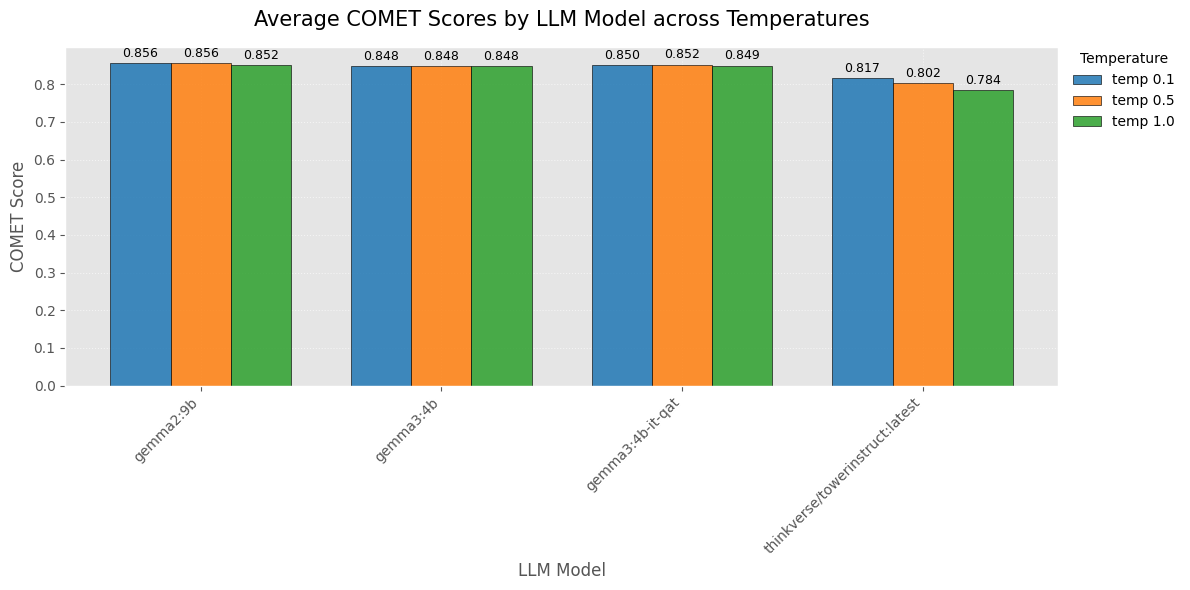

In [34]:
# Base directory for COMET score CSV files:
dir = "../data/difftemps/csv/"

# List of temperatures to process:
temps = [0.1, 0.5, 1.0]

# Define color palette (first four colors):
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Dictionary to store mean COMET scores per temperature:
comet_data = {}

# Load COMET CSV files:
for temp in temps:
    file_path = os.path.join(dir, f"mean_comet_scores_difftemps_temp{temp}.csv")

    if not os.path.exists(file_path):
        print(f"⚠️ Missing COMET file for temperature {temp}. Skipping...")
        continue

    df = pd.read_csv(file_path)

    # Transpose if necessary (one-row CSV with models as columns):
    if df.shape[0] == 1:
        df = df.T.reset_index()
        df.columns = ["Model", "COMET_Score"]

    # Store series in dictionary (Model as index):
    comet_data[temp] = df.set_index("Model")["COMET_Score"]

# Combine all temperature data into a single DataFrame:
if not comet_data:
    print("⚠️ No COMET data available for plotting.")
else:
    merged_df = pd.DataFrame(comet_data)
    merged_df.columns = [f"temp {t}" for t in merged_df.columns]  # rename columns for clarity

    # --- Create grouped barplot (triple bars per model): ---
    plt.figure(figsize=(12, 6))
    plt.style.use('ggplot')

    # X positions for each model:
    x = range(len(merged_df.index))
    width = 0.25  # width of each bar

    # Plot one set of bars per temperature:
    for i, col in enumerate(merged_df.columns):
        plt.bar(
            [pos + i * width for pos in x],
            merged_df[col],
            width=width,
            label=col,
            color=colors[i % len(colors)],
            edgecolor="black",
            alpha=0.85
        )

    # Add titles and labels:
    plt.title("Average COMET Scores by LLM Model across Temperatures", fontsize=15, pad=15)
    plt.xlabel("LLM Model", fontsize=12)
    plt.ylabel("COMET Score", fontsize=12)
    plt.xticks([pos + width for pos in x], merged_df.index, rotation=45, ha="right")

    # Add gridlines:
    plt.grid(True, linestyle=":", alpha=0.6, which="both")

    # Annotate bars with exact values:
    for i, col in enumerate(merged_df.columns):
        for j, val in enumerate(merged_df[col]):
            plt.text(
                j + i * width,
                val + (max(merged_df.max()) * 0.01),
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    # Move legend outside the plot, top-right:
    plt.legend(
        title="Temperature",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

#### Elapsed times (latency) by model bar graph per temperature

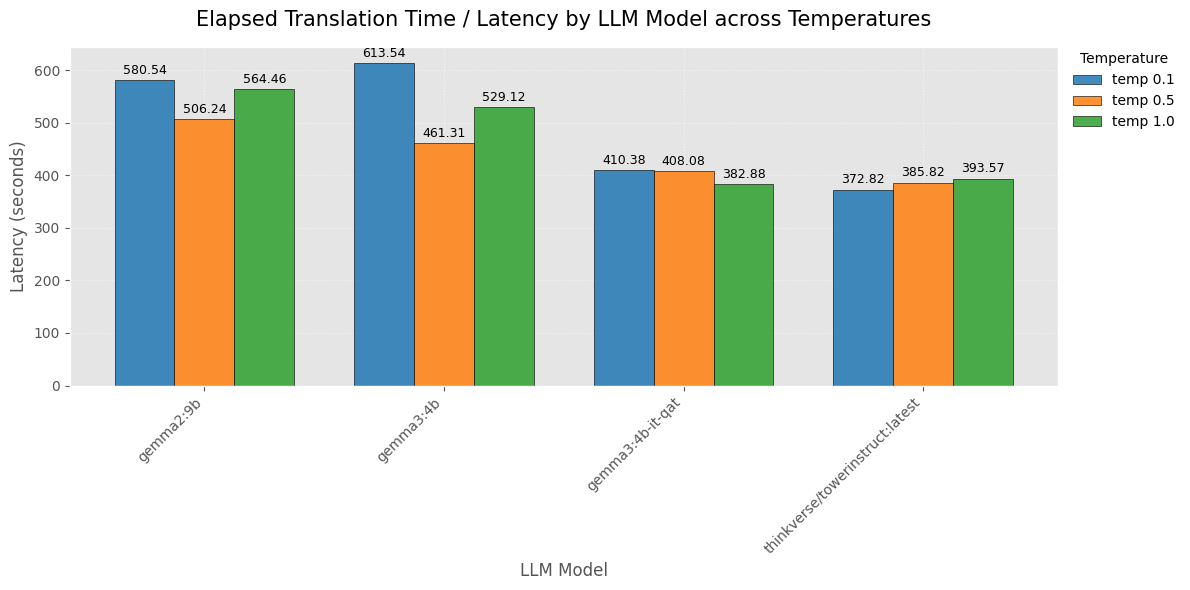

In [35]:
# Dictionary to store elapsed time per temperature:
elapsed_data = {}

# Load elapsed time CSV files:
for temp in temps:
    file_path = os.path.join(dir, f"elapsed_times_temp{temp}.csv")

    if not os.path.exists(file_path):
        print(f"⚠️ Missing elapsed time file for temperature {temp}. Skipping...")
        continue

    df = pd.read_csv(file_path)

    # Transpose if models are columns (one-row CSV):
    if df.shape[0] == 1:
        df = df.T.reset_index()
        df.columns = ["Model", "Elapsed_Time"]

    elapsed_data[temp] = df.set_index("Model")["Elapsed_Time"]

# Combine all temperatures into a single DataFrame:
if not elapsed_data:
    print("⚠️ No elapsed time data available for plotting.")
else:
    merged_df = pd.DataFrame(elapsed_data)
    merged_df.columns = [f"temp {t}" for t in merged_df.columns]

    # --- Create grouped barplot (triple bars per model): ---
    plt.figure(figsize=(12, 6))
    plt.style.use('ggplot')

    x = range(len(merged_df.index))
    width = 0.25  # width of each bar

    # Plot bars per temperature:
    for i, col in enumerate(merged_df.columns):
        plt.bar(
            [pos + i * width for pos in x],
            merged_df[col],
            width=width,
            label=col,
            color=colors[i % len(colors)],
            edgecolor="black",
            alpha=0.85
        )

    # Titles and labels:
    plt.title("Elapsed Translation Time / Latency by LLM Model across Temperatures", fontsize=15, pad=15)
    plt.xlabel("LLM Model", fontsize=12)
    plt.ylabel("Latency (seconds)", fontsize=12)
    plt.xticks([pos + width for pos in x], merged_df.index, rotation=45, ha="right")

    # Gridlines:
    plt.grid(True, linestyle=":", alpha=0.6, which="both")

    # Annotate bars with elapsed times:
    for i, col in enumerate(merged_df.columns):
        for j, val in enumerate(merged_df[col]):
            plt.text(
                j + i * width,
                val + (max(merged_df.max()) * 0.01),
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    # Legend outside top-right:
    plt.legend(
        title="Temperature",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

#### COMET scores boxplot per model and temperature

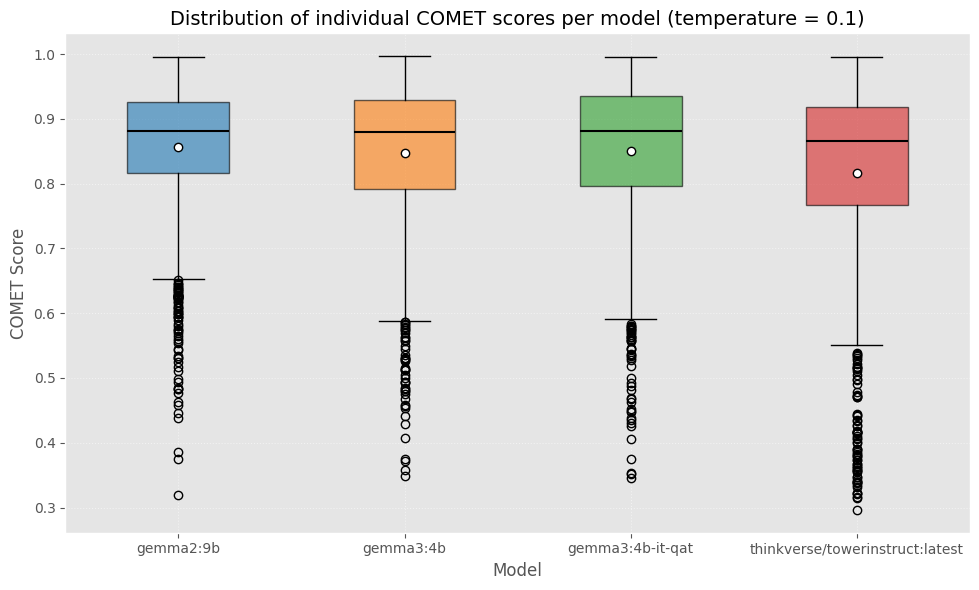

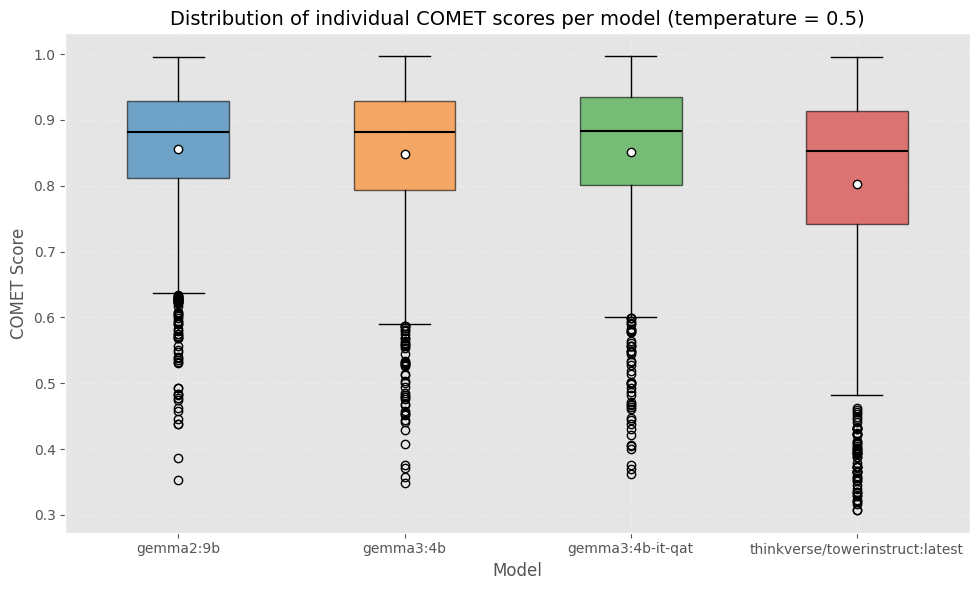

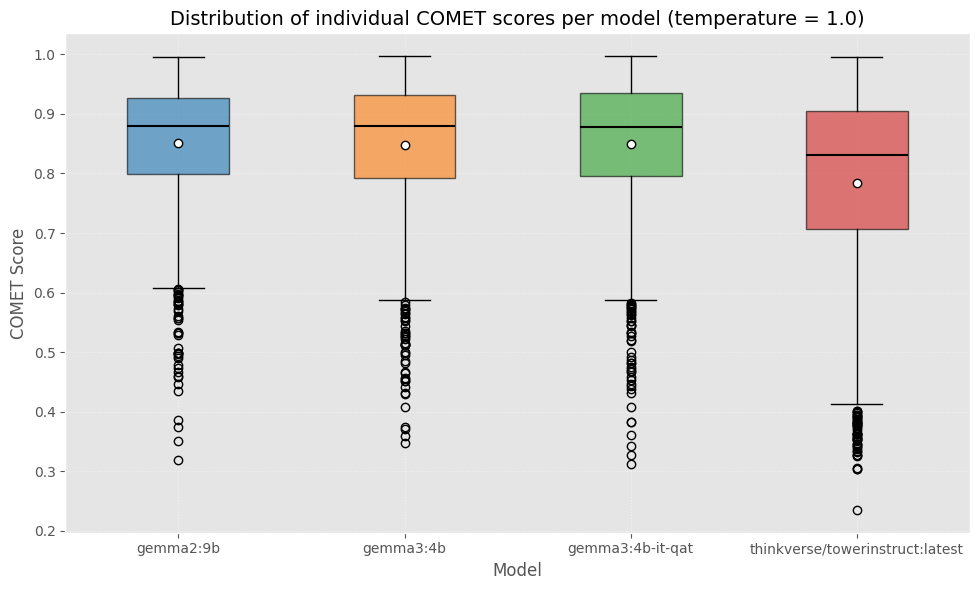

In [30]:
# Iterate through all temperature values:
for temp in temps:
    file_path = os.path.join(dir, f"individual_comet_scores_difftemps_temp{temp}.csv")

    # Check if file exists:
    if not os.path.exists(file_path):
        print(f"⚠️ Missing individual COMET score file for temperature {temp}. Skipping...")
        continue

    # Load the CSV containing the individual scores:
    scores_df = pd.read_csv(file_path)

    # Convert stringified lists to actual Python lists:
    scores_data = {}
    for model in scores_df.columns:
        try:
            scores_data[model] = ast.literal_eval(scores_df[model].iloc[0])
        except Exception as e:
            print(f"⚠️ Could not parse scores for {model}: {e}")
            continue

    # Skip if no valid data:
    if not scores_data:
        print(f"⚠️ No valid COMET data found for temperature {temp}. Skipping...")
        continue

    # --- Create boxplot for each model: ---
    plt.figure(figsize=(10, 6))

    # Generate the boxplot using the parsed scores:
    box = plt.boxplot(
        [scores_data[model] for model in scores_data.keys()],  # Each model’s scores:
        tick_labels=list(scores_data.keys()),                  # Model names as x-axis labels:
        patch_artist=True,
        showmeans=True,
        medianprops=dict(color="black", linewidth=1.5),
        meanprops=dict(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=6),
    )

    # Apply distinct colors to each box:
    for patch, color in zip(box["boxes"], colors[:len(scores_data)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    # Add grid and labels:
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.ylabel("COMET Score", fontsize=12)
    plt.xlabel("Model", fontsize=12)
    plt.title(f"Distribution of individual COMET scores per model (temperature = {temp})", fontsize=14)
    plt.tight_layout()

    # Display the boxplot:
    plt.show()


#### TER scores in a bar graph per temperature

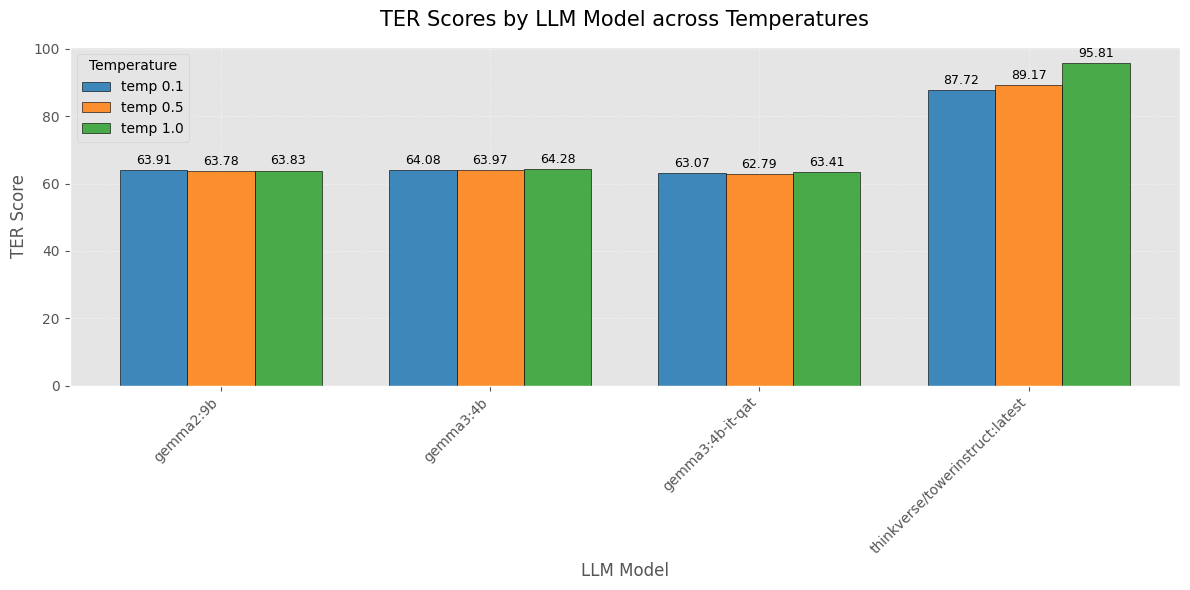

In [31]:
# Dictionary to store TER data for each temperature:
ter_data = {}

# Load TER CSV files:
for temp in temps:
    file_path = os.path.join(dir, f"ter_scores_difftemps_temp{temp}.csv")

    if not os.path.exists(file_path):
        print(f"⚠️ Missing TER file for temperature {temp}. Skipping...")
        continue

    df = pd.read_csv(file_path)

    # Each CSV contains one row with models as columns → convert to Series:
    if df.shape[0] == 1:
        df = df.T.reset_index()
        df.columns = ["Model", "TER_Score"]

    ter_data[temp] = df.set_index("Model")["TER_Score"]

# Combine all temperature data into a single DataFrame:
if not ter_data:
    print("⚠️ No TER data available for plotting.")
else:
    merged_df = pd.DataFrame(ter_data)
    merged_df.columns = [f"temp {t}" for t in merged_df.columns]  # rename columns for clarity

    # --- Create a grouped barplot comparing TER across temperatures: ---
    plt.figure(figsize=(12, 6))
    plt.style.use('ggplot')

    # X positions for each model:
    x = range(len(merged_df.index))
    width = 0.25  # width of each bar

    # Plot one set of bars per temperature:
    for i, col in enumerate(merged_df.columns):
        plt.bar(
            [pos + i * width for pos in x],
            merged_df[col],
            width=width,
            label=col,
            color=colors[i % len(colors)],
            edgecolor="black",
            alpha=0.85
        )

    # Add titles and labels:
    plt.title("TER Scores by LLM Model across Temperatures", fontsize=15, pad=15)
    plt.xlabel("LLM Model", fontsize=12)
    plt.ylabel("TER Score", fontsize=12)
    plt.xticks([pos + width for pos in x], merged_df.index, rotation=45, ha="right")

    # Add gridlines:
    plt.grid(True, linestyle=":", alpha=0.6, which="both")

    # Add numeric labels on top of each bar:
    for i, col in enumerate(merged_df.columns):
        for j, val in enumerate(merged_df[col]):
            plt.text(
                j + i * width,
                val + (max(merged_df.max()) * 0.01),
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    plt.legend(title="Temperature")
    plt.tight_layout()
    plt.show()